In [48]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
import numpy as np
import yaml
import json
import matplotlib as mpl

with open("../plotting_config.yaml", "r") as fp:
    config = yaml.safe_load(fp)

mpl.rcParams["svg.hashsalt"] = "42"

essential = [
    "cultural_institutions",
    "drugstores",
    "groceries",
    "healthcare",
    "parks",
    "religious_organizations",
    "restaurants",
    "schools",
    "services",
]


def is_accessable(x):
    result = 0
    if x > 0:
        result = 1
    return result


def generate_access_variables(data: pd.DataFrame) -> pd.DataFrame:
    copy = data.copy()
    for t in ["_multimodal", "_walk15"]:
        for e in essential:
            copy[e + t + "_d"] = copy[e + t].apply(is_accessable)

    copy["multimodal_sum"] = copy[[f"{i}_multimodal_d" for i in essential]].sum(axis=1)
    copy["walk_sum"] = copy[[f"{i}_walk15_d" for i in essential]].sum(axis=1)

    copy["multimodal_all"] = copy[[f"{i}_multimodal" for i in essential]].sum(axis=1)
    copy["walk_all"] = copy[[f"{i}_walk15" for i in essential]].sum(axis=1)

    return copy

In [2]:
bud = pd.read_csv("../output/budapest/20250428/indicators_with_ses.csv")
hel = pd.read_csv("../output/helsinki/20250428/indicators_with_ses.csv")
mad = pd.read_csv("../output/madrid/20250415/indicators_with_ses.csv")

bud = generate_access_variables(bud)
hel = generate_access_variables(hel)
mad = generate_access_variables(mad)

In [3]:
# labels=["6 or less", "7", "8", "9"],
# bud["multimodal_sum_bin"] = pd.cut(bud["multimodal_sum"], bins=[-1, 6, 7, 8, 9], labels=["6 or less", "7", "8", "9"], right=True)

In [4]:
b = bud[["stop_id", "multimodal_all", "multimodal_sum"]].copy()
b["city"] = "Budapest"
b["type"] = "multimodal"
h = hel[["stop_id", "multimodal_all", "multimodal_sum"]].copy()
h["city"] = "Helsinki"
h["type"] = "multimodal"
m = mad[["stop_id", "multimodal_all", "multimodal_sum"]].copy()
m["city"] = "Madrid"
m["type"] = "multimodal"
mm = pd.concat([b, h, m])
mm = mm.rename(columns={"multimodal_all": "access_all", "multimodal_sum": "access_sum"})
b = bud[["stop_id", "walk_all", "walk_sum"]].copy()
b["city"] = "Budapest"
b["type"] = "walk15"
h = hel[["stop_id", "walk_all", "walk_sum"]].copy()
h["city"] = "Helsinki"
h["type"] = "walk15"
m = mad[["stop_id", "walk_all", "walk_sum"]].copy()
m["city"] = "Madrid"
m["type"] = "walk15"
w15 = pd.concat([b, h, m])
w15 = w15.rename(columns={"walk_all": "access_all", "walk_sum": "access_sum"})
to_plot = pd.concat([mm, w15])
to_plot["access_all_log"] = np.log10(to_plot["access_all"])

In [ ]:
to_plot["bin"] = pd.cut(
    to_plot["access_sum"],
    bins=[-1, 6, 7, 8, 9],
    labels=["6 or less", "7", "8", "9"],
    right=True,
)

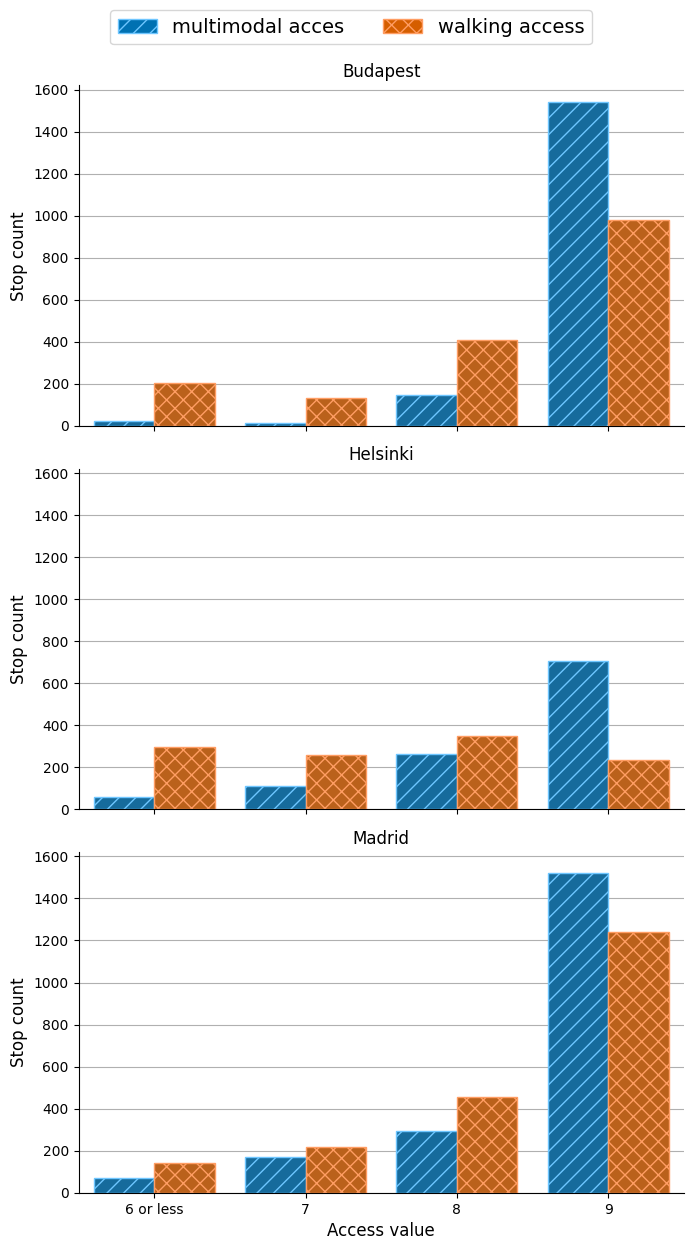

In [ ]:
tp2 = (
    to_plot.groupby(["city", "type", "bin"], observed=False)["stop_id"]
    .count()
    .reset_index()
)
g = sns.catplot(
    data=tp2,
    kind="bar",
    x="bin",
    y="stop_id",
    hue="type",
    height=4,
    aspect=1.75,
    palette=["#0071b2", "#d55e00"],
    row="city",
    legend=False,
)
hatches = ["//", "xx"]
hatches = [hatches[0]] * 4 + [hatches[1]] * 4
hatch_colors = ["#6ec6ff", "#ff9d63"]
hatch_colors = [hatch_colors[0]] * 4 + [hatch_colors[1]] * 4

for title, a in g.axes_dict.items():
    a.grid(axis="y")
    a.set_axisbelow(True)
    a.set_xlabel("Access value", fontsize=12)
    a.set_ylabel("Stop count", fontsize=12)
    a.set_title(title)

    for i, artist in enumerate(a.patches):
        artist.set_hatch(hatches[i])
        artist.set_edgecolor(hatch_colors[i])

elements = [
    Patch(color="#0071b2", label="multimodal acces", hatch="//", ec=hatch_colors[0]),
    Patch(color="#d55e00", label="walking access", hatch="xx", ec=hatch_colors[4]),
]
_ = g.axes_dict["Budapest"].legend(
    handles=elements,
    ncols=2,
    loc="upper center",
    bbox_to_anchor=(0.45, 1.25),
    fontsize=14,
)
# _ = g.axes_dict["Madrid"].legend(handles=elements, ncols=2, loc="upper center", bbox_to_anchor=(0.5, -0.2), fontsize=14)

for i in ["png", "svg", "pdf"]:
    g.savefig(
        f"../output/figures/access_by_cat_num.{i}", metadata=config["metadata"][i]
    )

In [7]:
# sns.kdeplot(data=to_plot.query("city=='Budapest'"), x="access_all_log", hue="type", fill=True)

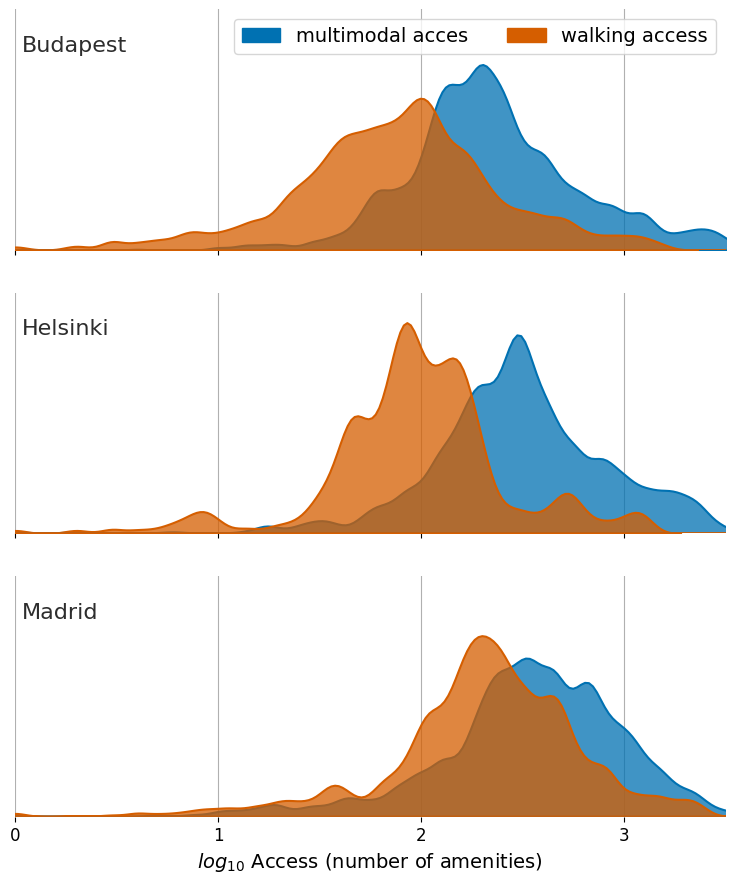

In [ ]:
# for square
# g = sns.FacetGrid(to_plot, row="city", hue="type", aspect=3.15, height=3, xlim=[0,3.5], palette=["#0071b2", "#d55e00"], legend_out=True)
# g.figure.subplots_adjust(hspace=0.05)
g = sns.FacetGrid(
    to_plot,
    row="city",
    hue="type",
    aspect=2.675,
    height=3,
    xlim=[0, 3.5],
    palette=["#0071b2", "#d55e00"],
    legend_out=True,
)

# Draw the densities in a few steps
g.map(
    sns.kdeplot,
    "access_all_log",
    bw_adjust=0.5,
    clip_on=True,
    fill=True,
    alpha=0.75,
    linewidth=1.5,
    legend=True,
)
# g.map(sns.kdeplot, "access_all_log", clip_on=True, color="w", lw=2, bw_adjust=.5)
g.refline(y=0, linewidth=2, linestyle="-", color=None, clip_on=True)


for city, ax in g.axes_dict.items():
    ax.text(
        0.01,
        0.85,
        city,
        color="#2d2d2d",
        fontdict=dict(size=16),
        ha="left",
        va="center",
        transform=ax.transAxes,
    )
    ax.set_facecolor("none")

elements = [
    Patch(color="#0071b2", label="multimodal acces"),
    Patch(color="#d55e00", label="walking access"),
]
g.axes_dict["Budapest"].legend(
    handles=elements, ncols=2, loc="upper right", fontsize=14
)
g.axes_dict["Budapest"].set_ylim(top=1.6)

# Set the subplots to overlap
# g.figure.subplots_adjust(hspace=-.25)

# Remove axes details that don't play well with overlap
g.set_titles("")
g.set(yticks=[], ylabel="")
g.set_xlabels("$log_{10}$ Access (number of amenities)", fontsize=14)
g.despine(bottom=True, left=True)
g.set(xticks=range(0, 4))
g.set_xticklabels(range(0, 4), fontsize=12)
for ax in g.axes.flatten():
    ax.set_axisbelow(True)
    ax.grid()

for i in ["png", "svg", "pdf"]:
    g.savefig(
        f"../output/figures/access_distribution_by_city.{i}",
        metadata=config["metadata"][i],
    )

In [ ]:
def prepare_gini_for_plotting(
    cities: list[pd.DataFrame], labels: list[str]
) -> pd.DataFrame:
    result = pd.DataFrame()
    for t in ["multimodal", "walk15"]:
        for d, label in zip(cities, labels):
            temp = d[["stop_id", f"gini_{t}"]].copy()
            temp["city"] = label
            temp["type"] = t
            temp = temp.rename(columns={f"gini_{t}": "gini"})
            result = pd.concat([result, temp])

    result["gini"] = result["gini"].apply(np.log10)
    return result

In [ ]:
mmm = prepare_gini_for_plotting(
    [
        bud[["stop_id", "gini_walk15", "gini_multimodal"]],
        bud[["stop_id", "gini_house_walk15", "gini_house_multimodal"]].rename(
            columns={
                "gini_house_walk15": "gini_walk15",
                "gini_house_multimodal": "gini_multimodal",
            }
        ),
        hel.rename(
            columns={
                "weighted_gini_walk": "gini_walk15",
                "weighted_gini_multi": "gini_multimodal",
            }
        ),
        mad.rename(
            columns={
                "weighted_gini_walk": "gini_walk15",
                "weighted_gini_multi": "gini_multimodal",
            }
        ),
    ],
    labels=["Budapest (experienced)", "Budapest", "Helsinki", "Madrid"],
)

In [ ]:
def plot_gini_distribution(
    data: pd.DataFrame, city: str, figsize: tuple[float, float]
) -> tuple[plt.Figure, plt.Axes]:
    fig, ax = plt.subplots(layout="constrained", figsize=figsize)
    sns.kdeplot(
        data=data[data["city"] == city].reset_index(drop=True),
        x="gini",
        hue="type",
        hue_order=["walk15", "multimodal"],
        palette=["#d55e00", "#0071b2"],
        clip_on=True,
        fill=True,
        alpha=0.75,
        linewidth=1.5,
        legend=True,
        ax=ax,
    )
    elements = [
        Patch(color="#0071b2", label="multimodal acces"),
        Patch(color="#d55e00", label="walking access"),
    ]
    ax.legend(handles=elements, ncols=1, loc="upper center", fontsize=13)
    ax.set_axisbelow(True)
    ax.grid(color="#e7e7e7")

    _ = ax.set_ylabel("")
    _ = ax.set_xlabel("$log_{10}$ Gini", fontsize=12)
    return fig, ax

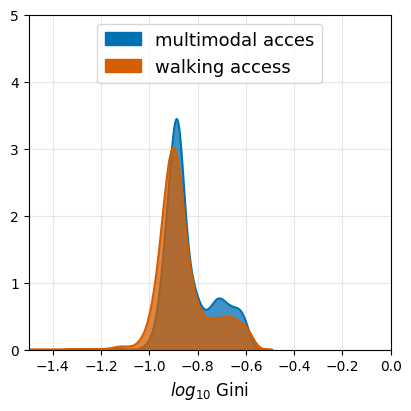

In [ ]:
fig, ax = plot_gini_distribution(mmm, "Budapest (experienced)", figsize=(4, 4))
ax.set_xlim([-1.5, -0])
_ = ax.set_ylim(top=5)
for i in ["png", "svg", "pdf"]:
    fig.savefig(
        f"../output/figures/gini_distribution_budapest_exp.{i}",
        metadata=config["metadata"][i],
    )

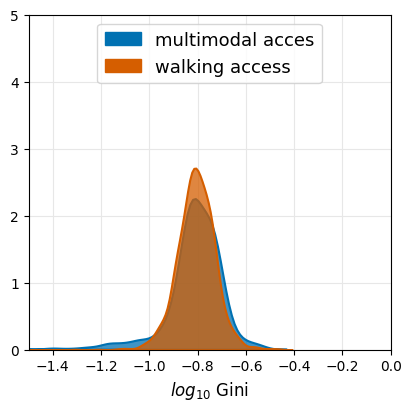

In [ ]:
fig, ax = plot_gini_distribution(mmm, "Budapest", figsize=(4, 4))
ax.set_xlim([-1.5, -0])
_ = ax.set_ylim(top=5)
for i in ["png", "svg", "pdf"]:
    fig.savefig(
        f"../output/figures/gini_distribution_budapest.{i}",
        metadata=config["metadata"][i],
    )

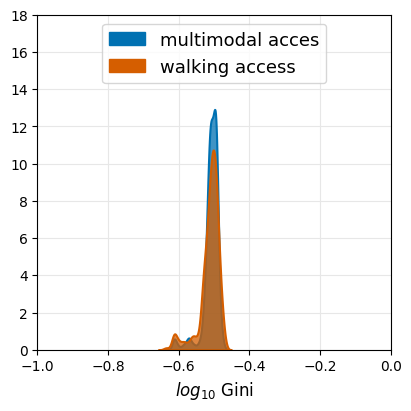

In [ ]:
fig, ax = plot_gini_distribution(mmm, "Helsinki", figsize=(4, 4))
ax.set_xlim([-1, 0])
_ = ax.set_ylim(top=18)
for i in ["png", "svg", "pdf"]:
    fig.savefig(
        f"../output/figures/gini_distribution_helsinki.{i}",
        metadata=config["metadata"][i],
    )

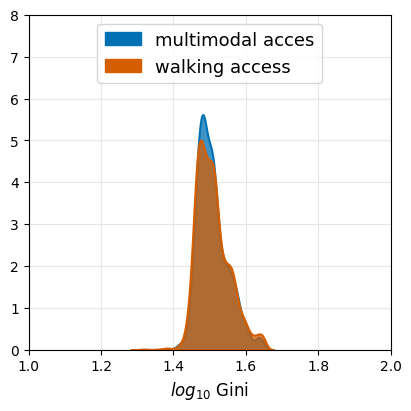

In [ ]:
fig, ax = plot_gini_distribution(mmm, "Madrid", figsize=(4, 4))
ax.set_xlim([1, 2])
_ = ax.set_ylim(top=8)
for i in ["png", "svg", "pdf"]:
    fig.savefig(
        f"../output/figures/gini_distribution_madrid.{i}",
        metadata=config["metadata"][i],
    )

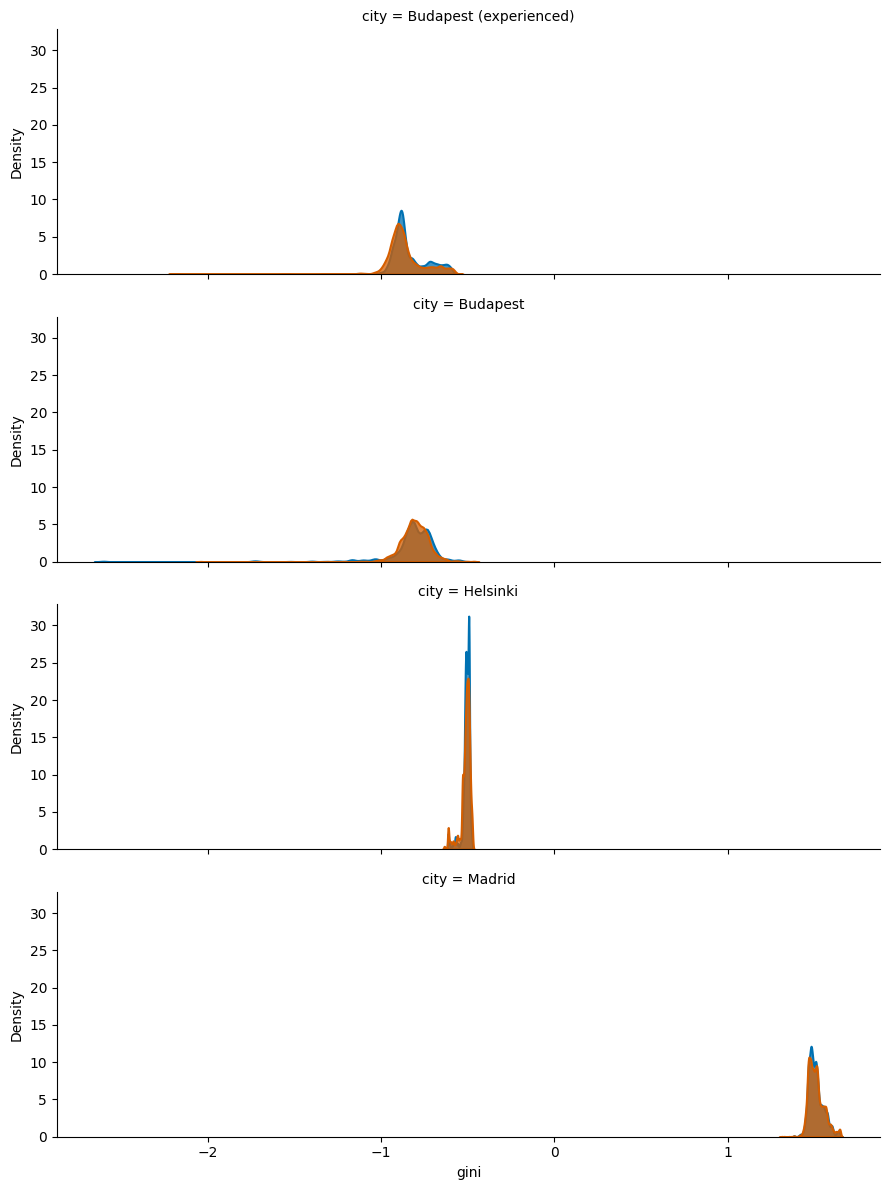

In [ ]:
g = sns.FacetGrid(
    mmm,
    row="city",
    hue="type",
    aspect=3,
    height=3,
    palette=["#0071b2", "#d55e00"],
    legend_out=True,
)
g.map(
    sns.kdeplot,
    "gini",
    bw_adjust=0.5,
    clip_on=True,
    fill=True,
    alpha=0.75,
    linewidth=1.5,
    legend=True,
)

In [ ]:
bud["distance_betweenness_bin"] = pd.qcut(
    np.log10(bud["distance_betweenness"]).tolist(), 2, labels=["1", "2"]
)

In [ ]:
to_plot2 = pd.DataFrame()
for x, city in zip([bud, hel, mad], ["Budapest", "Helsinki", "Madrid"]):
    x["distance_betweenness_bin"] = pd.qcut(
        np.log10(x["distance_betweenness"]).tolist(), 2, labels=["1", "2"]
    )
    temp = x[["stop_id", "distance_betweenness_bin", "ellipticity"]].copy()
    temp["city"] = city
    to_plot2 = pd.concat([to_plot2, temp])

In [19]:
to_plot2

,stop_id,distance_betweenness_bin,ellipticity,city
0,007877,1,0.8734,Budapest
1,007879,2,0.4497,Budapest
2,007881,1,0.6902,Budapest
3,007883,1,0.5772,Budapest
4,007884,1,0.4033,Budapest
...,...,...,...,...
2052,17643,2,0.8385,Madrid
2053,17688,2,0.5311,Madrid
2054,18927,2,0.8544,Madrid
2055,18928,2,0.7243,Madrid


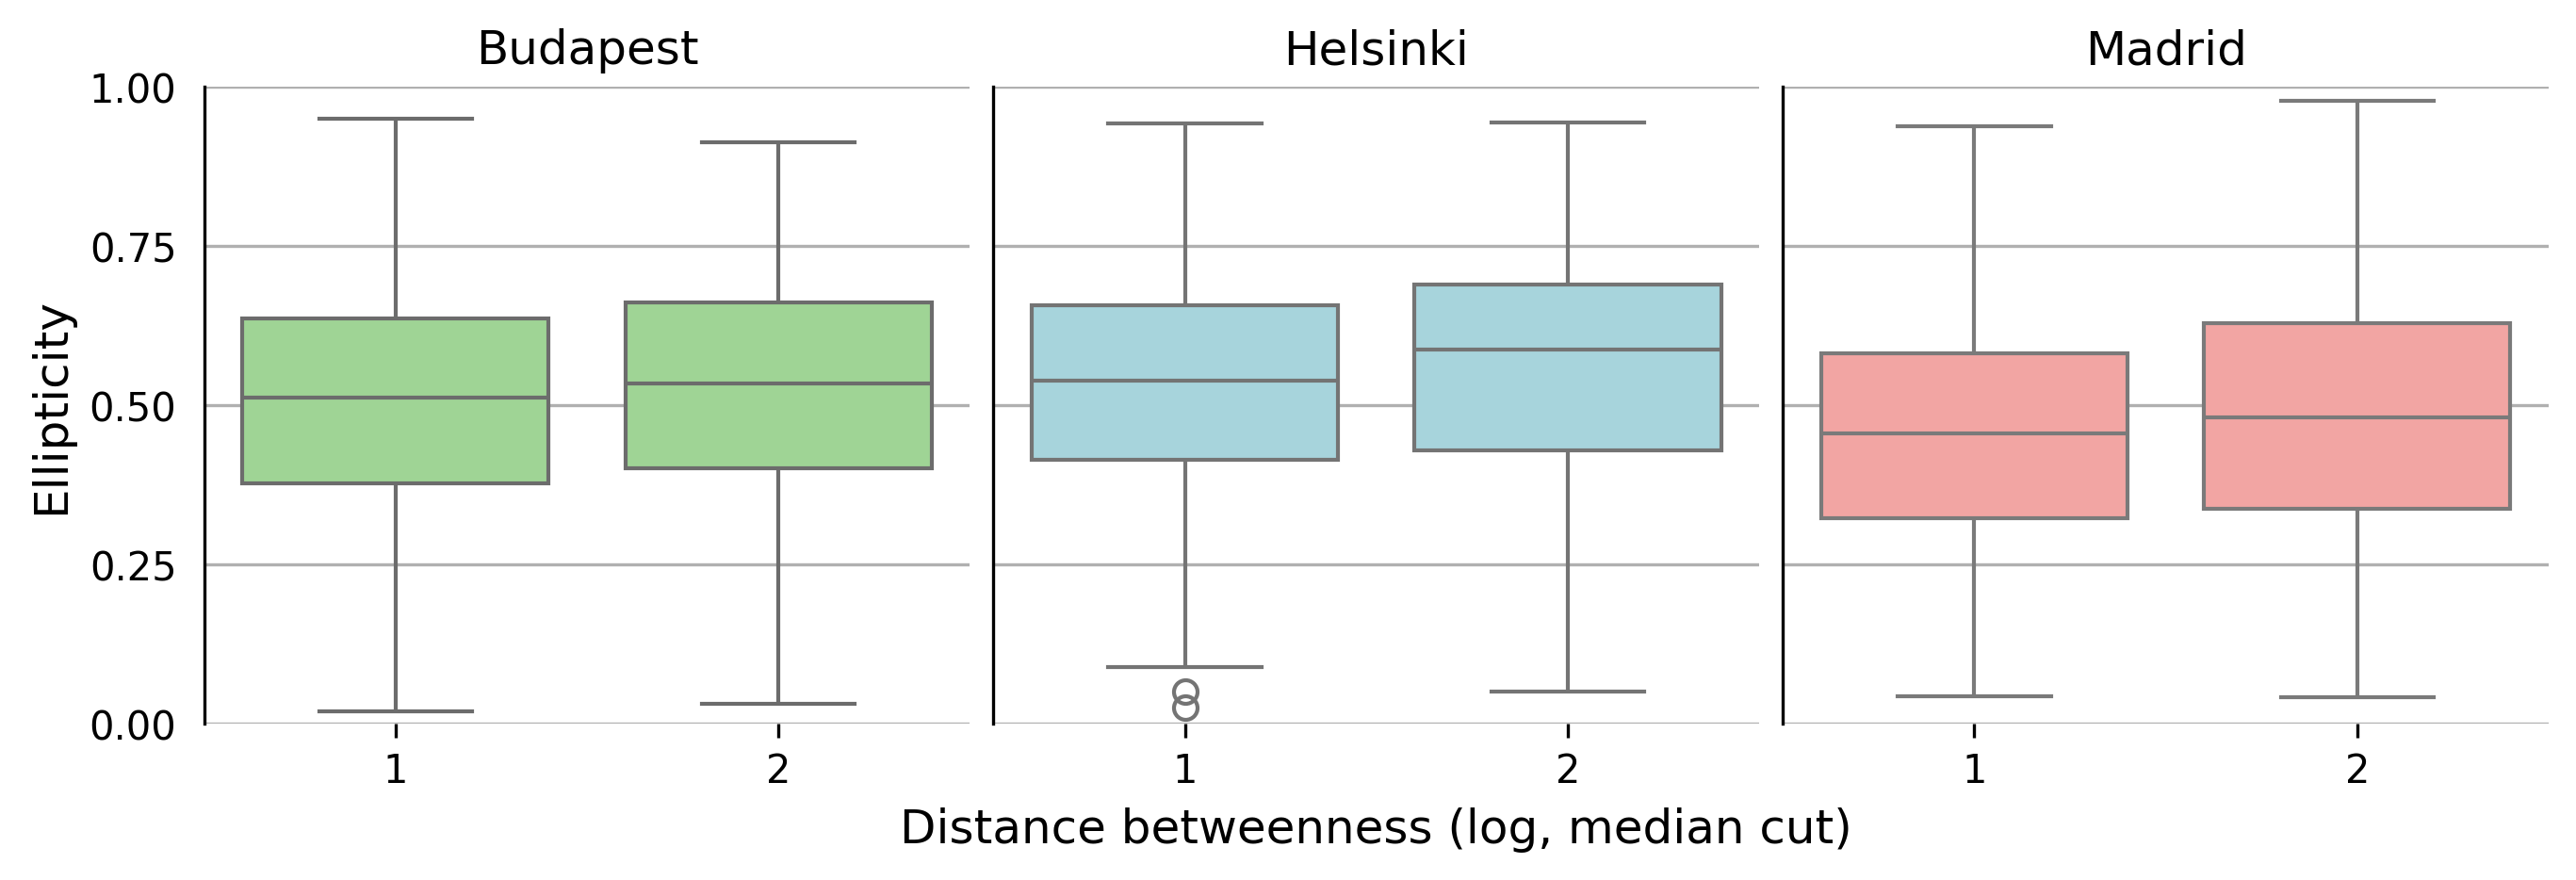

In [ ]:
colors = ["#cc79a7", "#56b4e9", "#009e73"]
colors = ["#98df8a", "#9edae5", "#ff9896"]
fig, axs = plt.subplots(
    ncols=3, layout="constrained", figsize=(9, 3), dpi=300, sharey=True
)
for d, a, c, t in zip([bud, hel, mad], axs, colors, ["Budapest", "Helsinki", "Madrid"]):
    sns.boxplot(
        data=d,
        x="distance_betweenness_bin",
        y="ellipticity",
        ax=a,
        color=c,
    )
    a.set_ylim([0, 1])
    a.set_yticks(np.arange(0, 1.2, 0.25))
    a.set_xlabel("")
    a.set_ylabel("Ellipticity", fontsize=12)
    a.set_title(t)
    a.set_axisbelow(True)
    a.grid(axis="y")
    a.tick_params(
        axis="y", which="both", bottom=False, top=False, left=False, right=False
    )
_ = axs[1].set_xlabel("Distance betweenness (log, median cut)", fontsize=12)

sns.despine(fig, axs[2], top=True, right=True, left=False, bottom=True)
for i in ["png", "svg", "pdf"]:
    fig.savefig(
        f"../output/figures/ellipticity_by_distance_betweenness.{i}",
        metadata=config["metadata"][i],
    )

In [46]:
values = {"Budapest": {}, "Helsinki": {}, "Madrid": {}}
for d, t in zip([bud, hel, mad], ["Budapest", "Helsinki", "Madrid"]):
    for i in ["1", "2"]:
        values[t][i] = {}
        values[t][i]["mean"] = (
            d[d["distance_betweenness_bin"] == i]["ellipticity"].mean().round(4)
        )
        values[t][i]["std"] = (
            d[d["distance_betweenness_bin"] == i]["ellipticity"].std().round(4)
        )
        values[t][i]["q1"] = (
            d[d["distance_betweenness_bin"] == i]["ellipticity"]
            .quantile(q=0.25)
            .round(4)
        )
        values[t][i]["median"] = (
            d[d["distance_betweenness_bin"] == i]["ellipticity"].median().round(4)
        )
        values[t][i]["q3"] = (
            d[d["distance_betweenness_bin"] == i]["ellipticity"]
            .quantile(q=0.75)
            .round(4)
        )

In [49]:
with open("../output/figures/ellipticity_by_distance_betweenness.json", "w") as fp:
    json.dump(values, fp, indent=2)

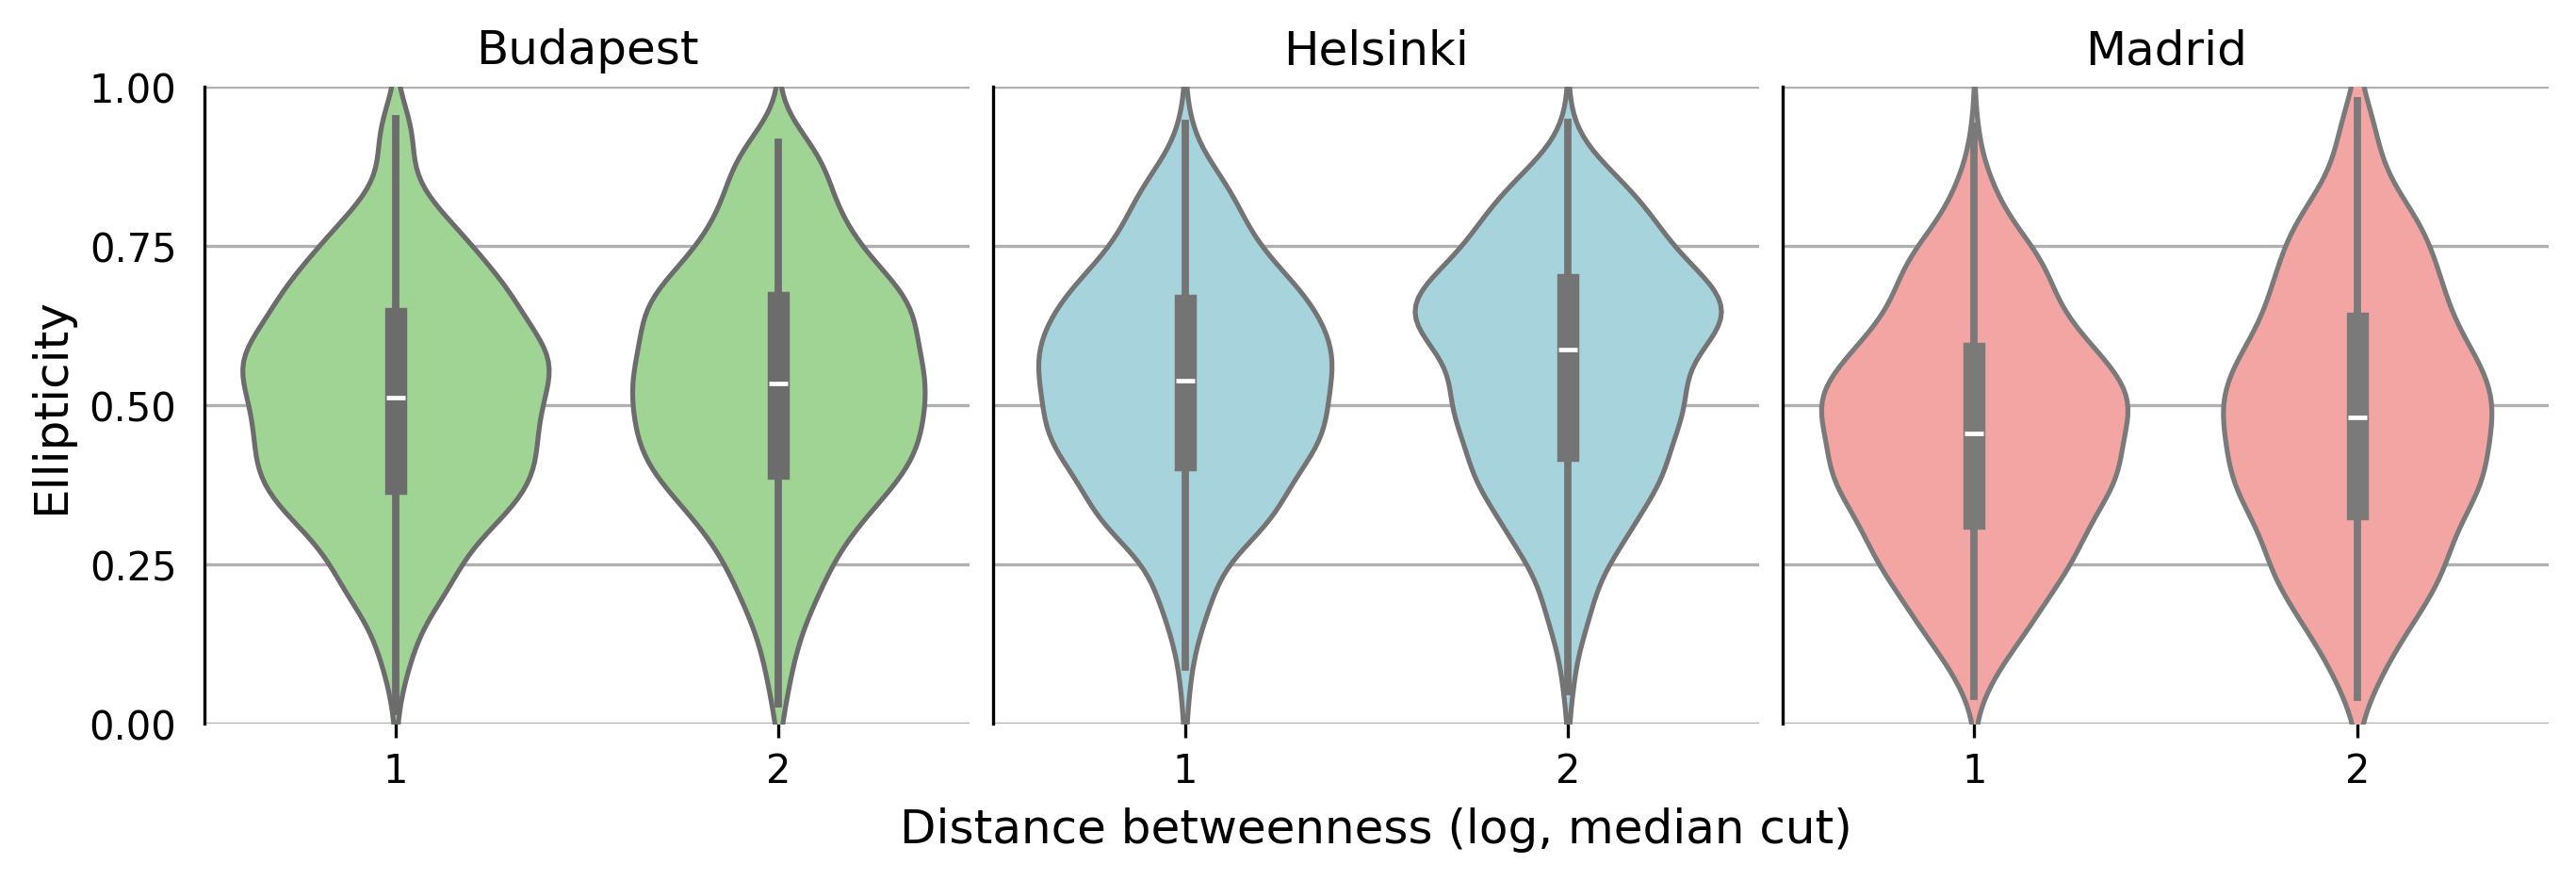

In [ ]:
colors = ["#98df8a", "#9edae5", "#ff9896"]
fig, axs = plt.subplots(
    ncols=3, layout="constrained", figsize=(9, 3), dpi=300, sharey=True
)
for d, a, c, t in zip([bud, hel, mad], axs, colors, ["Budapest", "Helsinki", "Madrid"]):
    sns.violinplot(
        data=d,
        x="distance_betweenness_bin",
        y="ellipticity",
        ax=a,
        color=c,
    )
    a.set_ylim([0, 1])
    a.set_yticks(np.arange(0, 1.2, 0.25))
    a.set_xlabel("")
    a.set_ylabel("Ellipticity", fontsize=12)
    a.set_title(t)
    a.set_axisbelow(True)
    a.grid(axis="y")
    a.tick_params(
        axis="y", which="both", bottom=False, top=False, left=False, right=False
    )
_ = axs[1].set_xlabel("Distance betweenness (log, median cut)", fontsize=12)

sns.despine(fig, axs[2], top=True, right=True, left=False, bottom=True)
for i in ["png", "svg", "pdf"]:
    fig.savefig(
        f"../output/figures/ellipticity_by_distance_betweenness_violin.{i}",
        metadata=config["metadata"][i],
    )